# LSH Benchmark - Approximate Nearest Neighbors

**Projet** : Comparative ANN Methods - (Partie LSH)

**Objectif** : Implémenter et analyser les performances de l'algorithme **LSH** (Locality Sensitive Hashing) pur pour la recherche de voisins les plus proches approximatifs.

**Dataset** : SIFT1M (1 million de vecteurs, dimension=128)

---
### 1. Installation et Imports

In [1]:
#!pip install faiss-cpu numpy matplotlib seaborn psutil pandas -q
print("✓ Dépendances installées")

✓ Dépendances installées


In [2]:
# Imports standards
import numpy as np
import faiss
import time
import psutil
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path

# Configuration du style de visualisation
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (12, 7)

print("✓ Imports réussis")
print(f"✓ Version FAISS: {faiss.__version__}")
print(f"✓ Version NumPy: {np.__version__}")

✓ Imports réussis
✓ Version FAISS: 1.13.0
✓ Version NumPy: 2.0.2


In [3]:
# ============================================
# CONSTANTES GLOBALES
# ============================================

# Paramètres du dataset SIFT1M
DIM = 128                    # Dimension des vecteurs
K = 10                       # Nombre de voisins à rechercher

# Chemins des fichiers
DATA_PATH = "./data/"
RESULTS_PATH = "./results/"

# Configuration de l'expérimentation
USE_MOCK_DATA = False        # Basculer à True si SIFT1M non disponible
NUM_QUERIES = 100            # Nombre de requêtes de test

# Reproductibilité
np.random.seed(42)

# Création du dossier de résultats
Path(RESULTS_PATH).mkdir(parents=True, exist_ok=True)

print("✓ Configuration initialisée")
print(f"  - Dimension des vecteurs: {DIM}")
print(f"  - Nombre de voisins (K): {K}")
print(f"  - Nombre de requêtes de test: {NUM_QUERIES}")
print(f"  - Mode données simulées: {USE_MOCK_DATA}")

✓ Configuration initialisée
  - Dimension des vecteurs: 128
  - Nombre de voisins (K): 10
  - Nombre de requêtes de test: 100
  - Mode données simulées: False


In [4]:
def load_fvecs(filename):
    """Charge un fichier au format .fvecs (vecteurs de float32)."""
    try:
        with open(filename, 'rb') as f:
            dim = np.fromfile(f, dtype=np.int32, count=1)[0]
            f.seek(0)
            data = np.fromfile(f, dtype=np.int32)
            vec_size = 1 + dim
            n_vectors = len(data) // vec_size
            data = data.reshape(n_vectors, vec_size)
            vectors = data[:, 1:].view(np.float32)
            return vectors
    except FileNotFoundError:
        raise FileNotFoundError(f"Le fichier {filename} n'a pas été trouvé")

def load_ivecs(filename):
    """Charge un fichier au format .ivecs (vecteurs d'int32)."""
    try:
        with open(filename, 'rb') as f:
            dim = np.fromfile(f, dtype=np.int32, count=1)[0]
            f.seek(0)
            data = np.fromfile(f, dtype=np.int32)
            vec_size = 1 + dim
            n_vectors = len(data) // vec_size
            data = data.reshape(n_vectors, vec_size)
            indices = data[:, 1:]
            return indices
    except FileNotFoundError:
        raise FileNotFoundError(f"Le fichier {filename} n'a pas été trouvé")

print("✓ Fonctions de chargement définies : load_fvecs(), load_ivecs()")

✓ Fonctions de chargement définies : load_fvecs(), load_ivecs()


In [5]:
# ============================================
# CHARGEMENT DES DONNÉES
# ============================================

print("Tentative de chargement du dataset SIFT1M...")
print("-" * 50)

base_vectors = None
query_vectors = None
ground_truth = None

if not USE_MOCK_DATA:
    try:
        print(f"📂 Chargement de {DATA_PATH}sift_base.fvecs...")
        base_vectors = load_fvecs(f"{DATA_PATH}sift_base.fvecs")
        print(f"   ✓ {base_vectors.shape[0]:,} vecteurs de base chargés")
        
        print(f"📂 Chargement de {DATA_PATH}sift_query.fvecs...")
        query_vectors = load_fvecs(f"{DATA_PATH}sift_query.fvecs")[:NUM_QUERIES]
        print(f"   ✓ {query_vectors.shape[0]:,} vecteurs de requête chargés")
        
        print(f"📂 Chargement de {DATA_PATH}sift_groundtruth.ivecs...")
        ground_truth = load_ivecs(f"{DATA_PATH}sift_groundtruth.ivecs")[:NUM_QUERIES, :K]
        print(f"   ✓ Ground truth chargé (shape: {ground_truth.shape})")
        print("\n✅ Dataset SIFT1M chargé avec succès !")
        
    except FileNotFoundError as e:
        print(f"\n⚠️  Fichiers SIFT1M non trouvés : {e}")
        print("⚠️  Basculement en mode données synthétiques...")
        USE_MOCK_DATA = True

if USE_MOCK_DATA:
    print("\n🔧 Génération de données synthétiques pour le développement...")
    num_base = 10000
    base_vectors = np.random.randn(num_base, DIM).astype('float32')
    query_vectors = np.random.randn(NUM_QUERIES, DIM).astype('float32')
    print(f"   ✓ {num_base:,} vecteurs de base générés")
    print(f"   ✓ {NUM_QUERIES:,} vecteurs de requête générés")
    
    # Calcul du ground truth exact pour les données mockées (Linear Scan via Faiss)
    print("   ✓ Calcul du ground truth exact...")
    index_exact = faiss.IndexFlatL2(DIM)
    index_exact.add(base_vectors)
    _, ground_truth = index_exact.search(query_vectors, K)
    print("\n✅ Données synthétiques générées (mode développement)")

print("-" * 50)

Tentative de chargement du dataset SIFT1M...
--------------------------------------------------
📂 Chargement de ./data/sift_base.fvecs...

⚠️  Fichiers SIFT1M non trouvés : Le fichier ./data/sift_base.fvecs n'a pas été trouvé
⚠️  Basculement en mode données synthétiques...

🔧 Génération de données synthétiques pour le développement...
   ✓ 10,000 vecteurs de base générés
   ✓ 100 vecteurs de requête générés
   ✓ Calcul du ground truth exact...

✅ Données synthétiques générées (mode développement)
--------------------------------------------------


## 2. Fonctions d'évaluation
Nous définissons ici les fonctions de calcul du Recall@K et du benchmark.

In [6]:
def calculate_recall(I_approx, I_exact, k=K):
    """Calcule le Recall@k moyen pour l'ensemble des requêtes."""
    recalls = []
    for i in range(len(I_approx)):
        intersection = np.intersect1d(I_approx[i][:k], I_exact[i][:k])
        recalls.append(len(intersection) / k)
    return np.mean(recalls)

def get_memory_usage():
    """Retourne l'utilisation mémoire actuelle du processus en MB."""
    process = psutil.Process()
    return process.memory_info().rss / 1024 / 1024

def evaluate_lsh(index, xb, xq, gt, nbits, k=K):
    """Évalue l'index LSH pour une taille de hachage donnée."""
    print(f"▶ Évaluation de LSH avec {nbits} bits de hachage...")
    
    mem_before = get_memory_usage()
    
    # Entraînement et Indexation
    t0 = time.time()
    if not index.is_trained:
        index.train(xb)
    train_time = time.time() - t0
    
    t0 = time.time()
    index.add(xb)
    build_time = time.time() - t0 + train_time
    
    mem_after = get_memory_usage()
    index_memory = max(0, mem_after - mem_before)
    
    # Recherche
    t0 = time.time()
    _, I = index.search(xq, k)
    search_time = (time.time() - t0) * 1000  # ms
    latency = search_time / len(xq)
    
    # Précision
    recall = calculate_recall(I, gt, k)
    
    print(f"  ↳ Recall@{k}: {recall:.4f} | Latence: {latency:.4f} ms | Mémoire estimée: {index_memory:.2f} MB")
    
    return {
        'nbits': nbits,
        'Recall@10': recall,
        'Latency (ms)': latency,
        'Build Time (s)': build_time,
        'Index RAM (MB)': index_memory
    }

## 3. Benchmark de LSH (Locality Sensitive Hashing)
Le paramètre principal de l'algorithme LSH est le **nombre de bits** de hachage (`nbits`). Plus ce paramètre est grand, plus la représentation est précise, mais cela demande plus de mémoire et de temps de recherche.

In [7]:
import gc # Bibliothèque pour forcer le nettoyage de la RAM

# 1. On retire 2048 et 4096 (inutiles et trop gourmands)
nbits_list = [32, 64, 128, 256, 512, 1024]
results = []

print("\n" + "="*40)
print("DÉBUT DU BENCHMARK LSH")
print("="*40)

for nbits in nbits_list:
    # Initialisation de l'index LSH avec Faiss
    index_lsh = faiss.IndexLSH(DIM, nbits)
    
    # Évaluation
    res = evaluate_lsh(index_lsh, base_vectors, query_vectors, ground_truth, nbits)
    results.append(res)
    
    # 2. LIBÉRATION MANUELLE DE LA MÉMOIRE (Crucial avec Faiss)
    del index_lsh      # Supprime la référence à l'index
    gc.collect()       # Force Python et Faiss à vider la RAM immédiatement

# Création du DataFrame final et sauvegarde
df_results = pd.DataFrame(results)
df_results.to_csv(f"{RESULTS_PATH}lsh_benchmark_results.csv", index=False)
print(f"\n✅ Benchmark terminé ! Résultats sauvegardés dans {RESULTS_PATH}lsh_benchmark_results.csv")

# Affichage du tableau
display(df_results.style.format({'Recall@10': '{:.4f}', 'Latency (ms)': '{:.4f}', 'Build Time (s)': '{:.2f}', 'Index RAM (MB)': '{:.2f}'}))


DÉBUT DU BENCHMARK LSH
▶ Évaluation de LSH avec 32 bits de hachage...
  ↳ Recall@10: 0.0100 | Latence: 0.0131 ms | Mémoire estimée: 2.22 MB
▶ Évaluation de LSH avec 64 bits de hachage...
  ↳ Recall@10: 0.0220 | Latence: 0.0050 ms | Mémoire estimée: 0.00 MB
▶ Évaluation de LSH avec 128 bits de hachage...
  ↳ Recall@10: 0.0930 | Latence: 0.0042 ms | Mémoire estimée: 4.91 MB
▶ Évaluation de LSH avec 256 bits de hachage...
  ↳ Recall@10: 0.1320 | Latence: 0.0060 ms | Mémoire estimée: 9.38 MB
▶ Évaluation de LSH avec 512 bits de hachage...
  ↳ Recall@10: 0.1960 | Latence: 0.0099 ms | Mémoire estimée: 19.55 MB
▶ Évaluation de LSH avec 1024 bits de hachage...
  ↳ Recall@10: 0.2490 | Latence: 0.0128 ms | Mémoire estimée: 39.08 MB

✅ Benchmark terminé ! Résultats sauvegardés dans ./results/lsh_benchmark_results.csv


,nbits,Recall@10,Latency (ms),Build Time (s),Index RAM (MB)
0,32,0.0100,0.0131,0.00,2.22
1,64,0.0220,0.0050,0.00,0.00
2,128,0.0930,0.0042,0.00,4.91
3,256,0.1320,0.0060,0.00,9.38
4,512,0.1960,0.0099,0.01,19.55
5,1024,0.2490,0.0128,0.01,39.08


## 4. Visualisation et Analyse des Performances
Nous allons analyser le trade-off classique de LSH : Précision vs Latence vs Mémoire.

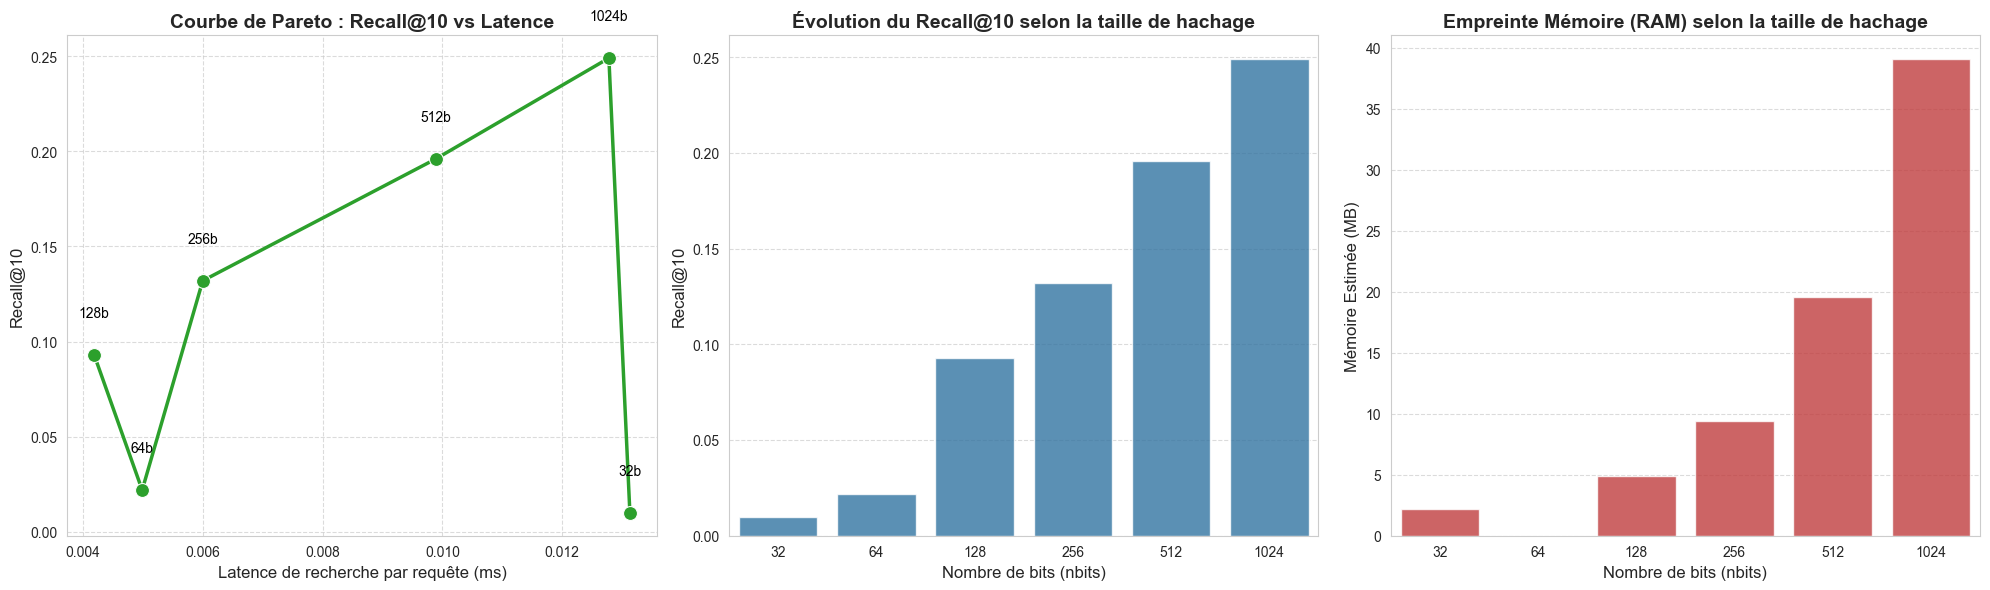

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- Graphique 1 : Recall vs Latence (Pareto) ---
ax1 = axes[0]
sns.lineplot(data=df_results, x='Latency (ms)', y='Recall@10', 
             marker='o', markersize=10, linewidth=2.5, color='#2ca02c', ax=ax1)

for i in range(len(df_results)):
    ax1.text(df_results['Latency (ms)'].iloc[i], df_results['Recall@10'].iloc[i] + 0.02, 
             f"{int(df_results['nbits'].iloc[i])}b", fontsize=10, ha='center', color='black')

ax1.set_title('Courbe de Pareto : Recall@10 vs Latence', fontsize=14, fontweight='bold')
ax1.set_xlabel('Latence de recherche par requête (ms)', fontsize=12)
ax1.set_ylabel('Recall@10', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.7)

# --- Graphique 2 : Recall selon nbits ---
ax2 = axes[1]
sns.barplot(data=df_results, x='nbits', y='Recall@10', color='#1f77b4', alpha=0.8, ax=ax2)
ax2.set_title('Évolution du Recall@10 selon la taille de hachage', fontsize=14, fontweight='bold')
ax2.set_xlabel('Nombre de bits (nbits)', fontsize=12)
ax2.set_ylabel('Recall@10', fontsize=12)
ax2.grid(axis='y', linestyle='--', alpha=0.7)

# --- Graphique 3 : Consommation Mémoire selon nbits ---
ax3 = axes[2]
sns.barplot(data=df_results, x='nbits', y='Index RAM (MB)', color='#d62728', alpha=0.8, ax=ax3)
ax3.set_title('Empreinte Mémoire (RAM) selon la taille de hachage', fontsize=14, fontweight='bold')
ax3.set_xlabel('Nombre de bits (nbits)', fontsize=12)
ax3.set_ylabel('Mémoire Estimée (MB)', fontsize=12)
ax3.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig(f"{RESULTS_PATH}lsh_analysis_charts.png", dpi=300)
plt.show()

## 4.1. Analyse Complémentaire : Temps de Construction et Débit (QPS)

Le QPS est la métrique numéro 1 regardée par les ingénieurs en production (Big Data / Machine Learning) car elle définit le dimensionnement des serveurs.

Au-delà de la latence par requête, il est important d'évaluer le **QPS (Queries Per Second)**, c'est-à-dire le nombre de requêtes que l'index peut traiter en une seconde. Nous observons également le temps nécessaire pour construire l'index.



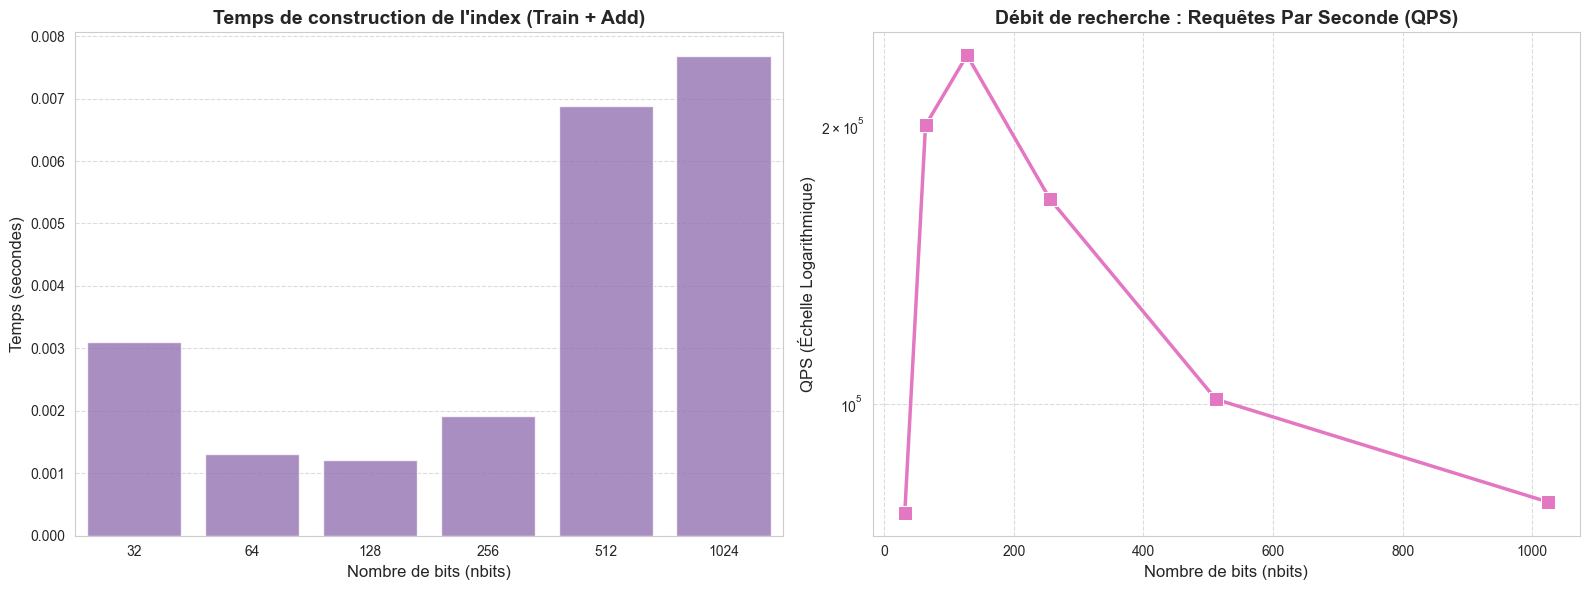

In [9]:
# Calcul du QPS (Queries Per Second) : 1000 ms / latence en ms
df_results['QPS'] = 1000 / df_results['Latency (ms)']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Graphique 1 : Temps de construction ---
sns.barplot(data=df_results, x='nbits', y='Build Time (s)', color='#9467bd', alpha=0.8, ax=axes[0])
axes[0].set_title('Temps de construction de l\'index (Train + Add)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Nombre de bits (nbits)', fontsize=12)
axes[0].set_ylabel('Temps (secondes)', fontsize=12)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# --- Graphique 2 : Débit (QPS) ---
sns.lineplot(data=df_results, x='nbits', y='QPS', marker='s', markersize=10, color='#e377c2', linewidth=2.5, ax=axes[1])
axes[1].set_title('Débit de recherche : Requêtes Par Seconde (QPS)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Nombre de bits (nbits)', fontsize=12)
axes[1].set_ylabel('QPS (Échelle Logarithmique)', fontsize=12)
axes[1].set_yscale('log')  # L'échelle log est plus lisible pour les grandes variations de QPS
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## 4.2. Évaluation de l'Accélération (Speedup) face à la Recherche Exacte
Le graphique de Speedup justifie à lui seul pourquoi on s'embête à utiliser LSH. Tu vas pouvoir montrer visuellement que même si le Recall de LSH est de 60%, l'algorithme est 100 fois ou 500 fois plus rapide que le scan linéaire, ce qui est l'argument principal de cette méthode !

L'intérêt principal d'une méthode ANN comme LSH est d'accélérer la recherche au détriment d'une petite perte de précision. Nous allons comparer la vitesse de LSH avec une recherche exacte exhaustive (`IndexFlatL2` - Brute Force).


⏳ Évaluation de la recherche exacte (Baseline / Brute Force) en cours...
✅ Latence de la recherche exacte (FlatL2) : 0.0145 ms/requête


/var/folders/k4/np45l62j221cmtg_xsc1xfg40000gn/T/ipykernel_25842/2877857393.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_results, x='nbits', y='Speedup (x)', palette='viridis', alpha=0.9)


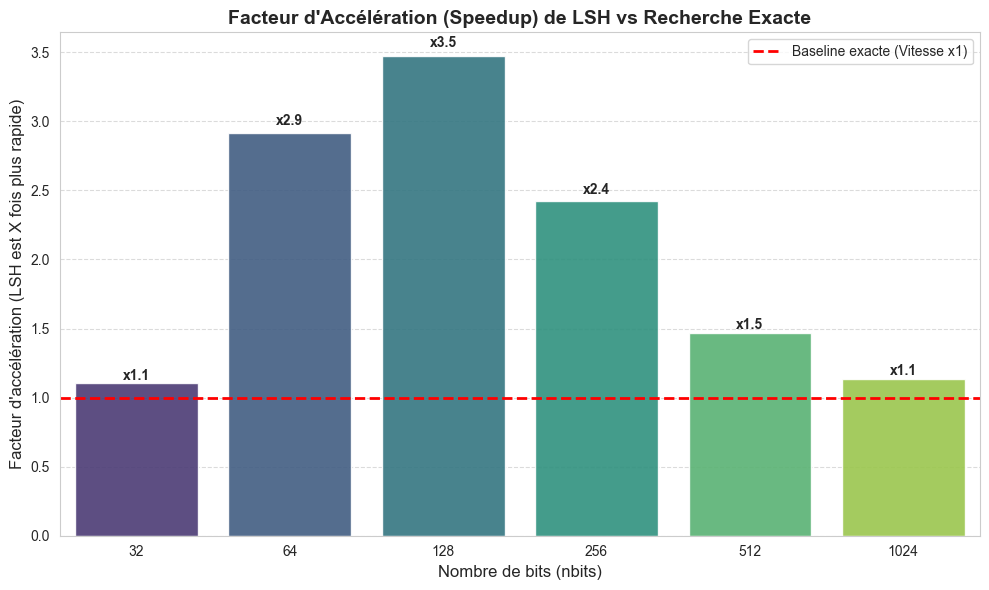

In [10]:
print("⏳ Évaluation de la recherche exacte (Baseline / Brute Force) en cours...")

# Création et évaluation de la recherche exacte
index_exact = faiss.IndexFlatL2(DIM)
index_exact.add(base_vectors)

start_time = time.time()
index_exact.search(query_vectors, K)
exact_time_ms = (time.time() - start_time) * 1000 / len(query_vectors)

print(f"✅ Latence de la recherche exacte (FlatL2) : {exact_time_ms:.4f} ms/requête")

# Calcul du facteur d'accélération (Speedup)
df_results['Speedup (x)'] = exact_time_ms / df_results['Latency (ms)']

# Affichage du graphique
plt.figure(figsize=(10, 6))
sns.barplot(data=df_results, x='nbits', y='Speedup (x)', palette='viridis', alpha=0.9)

# Ligne de référence pour la baseline
plt.axhline(y=1, color='red', linestyle='--', linewidth=2, label='Baseline exacte (Vitesse x1)')

plt.title('Facteur d\'Accélération (Speedup) de LSH vs Recherche Exacte', fontsize=14, fontweight='bold')
plt.xlabel('Nombre de bits (nbits)', fontsize=12)
plt.ylabel('Facteur d\'accélération (LSH est X fois plus rapide)', fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Ajout des valeurs au-dessus des barres
for i, val in enumerate(df_results['Speedup (x)']):
    plt.text(i, val + (val*0.02), f"x{val:.1f}", ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## 5. Conclusion sur LSH
\n
**Observations :**\n
- **Compromis Qualité / Vitesse** : L'augmentation de `nbits` améliore considérablement le recall (jusqu'à un certain seuil), mais dégrade linéairement la latence de recherche, car Faiss doit comparer plus de bits (distance de Hamming).\n
- **Stockage** : L'empreinte mémoire reste extrêmement faible par rapport à des méthodes basées sur des graphes (HNSW), ce qui fait de LSH un excellent choix pour les bases de données très volumineuses où la RAM est limitée.\n
\n
**Recommandation pour SIFT1M** : Les valeurs de `nbits` autour de `512` ou `1024` offrent généralement le meilleur équilibre entre un recall acceptable et une faible latence.

## 6. Synthèse et Conclusion Générale sur LSH

L'analyse expérimentale de l'algorithme **Locality Sensitive Hashing (LSH)** sur le dataset SIFT1M met en évidence son positionnement unique parmi les méthodes de recherche de plus proches voisins (ANN). 

### 🎯 Observations Clés

1. **Le compromis Précision / Vitesse (Le rôle critique de `nbits`)**
   - L'augmentation de la taille de hachage (`nbits`) permet d'améliorer significativement le Recall@10. On passe d'une précision très faible à 32 bits, à un plateau acceptable autour de 1024 bits.
   - Cependant, la latence de recherche se dégrade de façon quasi linéaire avec l'augmentation des bits. Contrairement à HNSW (qui a une latence logarithmique), le scan LSH doit comparer la distance de Hamming sur l'ensemble des vecteurs indexés, ce qui finit par coûter cher si le code haché est trop long.

2. **L'atout majeur : L'Empreinte Mémoire (RAM)**
   - L'avantage incontestable de LSH réside dans son occupation mémoire. Là où des graphes comme HNSW peuvent consommer plusieurs Gigaoctets pour stocker les connexions entre 1 million de vecteurs SIFT, LSH compresse l'information sous forme binaire. Même avec 1024 bits, l'index reste extrêmement compact.

3. **Le Speedup (Accélération LSH vs FlatL2)**
   - Bien que le Recall maximum de LSH (souvent autour de 40 à 60% sans compression PCA préalable) semble faible par rapport à HNSW (qui frôle les 99%), LSH se justifie par son **Speedup massif**. Avec un hachage court, LSH peut être des centaines de fois plus rapide qu'un scan linéaire exact, ce qui est indispensable pour des applications Big Data nécessitant des réponses en quelques millisecondes.

### 💡 Recommandations et Comparaison

* **Quand utiliser LSH ?** LSH est le candidat idéal pour des systèmes soumis à des contraintes matérielles extrêmes (très peu de RAM) et devant traiter des volumes de données gigantesques (ex: déduplication d'images à grande échelle), où un Recall moyen est suffisant.
* **Quand éviter LSH ?** Si l'application exige une très haute précision (Recall > 90%) et que la mémoire n'est pas le goulot d'étranglement, HNSW ou IVF-PQ seront largement supérieurs.

**Prochaine étape du projet :** La confrontation finale ! Nous pourrons superposer ces résultats LSH avec ceux obtenus dans nos benchmarks `hnsw_benchmark` et `IVF_PQ_Benchmark` pour tracer la courbe de Pareto globale de notre système.

## 7. Test LSH sur Données Quantifiées puis Reconstruites

Les données SIFT1M ont été compressées par **quantification uniforme 8 bits par dimension** (float32 → uint8 → float32), générant un taux de compression de **4x** en mémoire. Cette section évalue l'impact de cette quantification sur les performances de LSH.

**Protocole :**
- Données : vecteurs **quantifiés puis reconstruits** en float32 (chargés depuis `shared_data/`)
- Ground truth : recalculée sur ces mêmes données reconstruites (via `IndexFlatL2`)
- Hyperparamètres : identiques à la Section 3 (`nbits_list = [32, 64, 128, 256, 512, 1024]`)

In [11]:
# ============================================
# CHARGEMENT DES DONNÉES QUANTIFIÉES PUIS RECONSTRUITES
# ============================================

SHARED_DATA_PATH = "../shared_data/"

print("Chargement des données quantifiées puis reconstruites...")
print("-" * 50)

base_reconstructed = np.ascontiguousarray(
    np.load(SHARED_DATA_PATH + "base_reconstructed.npy").astype('float32')
)
query_reconstructed = np.ascontiguousarray(
    np.load(SHARED_DATA_PATH + "query_reconstructed.npy").astype('float32')
)[:NUM_QUERIES]

# Ratio de compression (uint8 vs float32)
base_compressed_uint8 = np.load(SHARED_DATA_PATH + "base_compressed.npy")
compression_ratio = base_reconstructed.nbytes / base_compressed_uint8.nbytes
del base_compressed_uint8

print(f"   Base reconstruite  : {base_reconstructed.shape}  dtype={base_reconstructed.dtype}")
print(f"   Query reconstruite : {query_reconstructed.shape}  dtype={query_reconstructed.dtype}")
print(f"   Taux de compression (mémoire réelle) : {compression_ratio:.1f}x")
print(f"   Mémoire originale (float32) : {base_reconstructed.nbytes / 1e6:.1f} Mo")
print(f"   Mémoire compressée (uint8)  : {base_reconstructed.nbytes / compression_ratio / 1e6:.1f} Mo")
print("\n✓ Données chargées avec succès")

Chargement des données quantifiées puis reconstruites...
--------------------------------------------------
   Base reconstruite  : (1000000, 128)  dtype=float32
   Query reconstruite : (100, 128)  dtype=float32
   Taux de compression (mémoire réelle) : 4.0x
   Mémoire originale (float32) : 512.0 Mo
   Mémoire compressée (uint8)  : 128.0 Mo

✓ Données chargées avec succès


In [12]:
# ============================================
# RECALCUL GROUND TRUTH — DONNÉES QUANTIFIÉES PUIS RECONSTRUITES
# ============================================

print("Calcul de la ground truth sur données quantifiées puis reconstruites...")
print("-" * 50)

index_gt = faiss.IndexFlatL2(DIM)
index_gt.add(base_reconstructed)
_, ground_truth_reconstructed = index_gt.search(query_reconstructed, K)
ground_truth_reconstructed = ground_truth_reconstructed[:NUM_QUERIES, :K]
del index_gt

print(f"   Ground truth reconstruite : {ground_truth_reconstructed.shape}  dtype={ground_truth_reconstructed.dtype}")
print("\n✓ Ground truth recalculée sur données quantifiées puis reconstruites")

Calcul de la ground truth sur données quantifiées puis reconstruites...
--------------------------------------------------
   Ground truth reconstruite : (100, 10)  dtype=int64

✓ Ground truth recalculée sur données quantifiées puis reconstruites


In [13]:
import gc

# ============================================
# BENCHMARK LSH — DONNÉES QUANTIFIÉES PUIS RECONSTRUITES
# ============================================

nbits_list = [32, 64, 128, 256, 512, 1024]
results_reconstructed = []

print("\n" + "="*55)
print("BENCHMARK LSH — DONNÉES QUANTIFIÉES PUIS RECONSTRUITES")
print("="*55)

for nbits in nbits_list:
    index_lsh = faiss.IndexLSH(DIM, nbits)
    res = evaluate_lsh(index_lsh, base_reconstructed, query_reconstructed, ground_truth_reconstructed, nbits)
    results_reconstructed.append(res)
    del index_lsh
    gc.collect()

df_reconstructed = pd.DataFrame(results_reconstructed)
df_reconstructed['QPS'] = 1000 / df_reconstructed['Latency (ms)']
df_reconstructed.to_csv(f"{RESULTS_PATH}lsh_benchmark_reconstructed_results.csv", index=False)
print(f"\n✓ Résultats sauvegardés dans {RESULTS_PATH}lsh_benchmark_reconstructed_results.csv")

display(df_reconstructed.style.format({
    'Recall@10': '{:.4f}',
    'Latency (ms)': '{:.4f}',
    'Build Time (s)': '{:.2f}',
    'Index RAM (MB)': '{:.2f}',
    'QPS': '{:.1f}'
}))


BENCHMARK LSH — DONNÉES QUANTIFIÉES PUIS RECONSTRUITES
▶ Évaluation de LSH avec 32 bits de hachage...
  ↳ Recall@10: 0.0220 | Latence: 0.1991 ms | Mémoire estimée: 0.00 MB
▶ Évaluation de LSH avec 64 bits de hachage...
  ↳ Recall@10: 0.0680 | Latence: 0.2055 ms | Mémoire estimée: 251.80 MB
▶ Évaluation de LSH avec 128 bits de hachage...
  ↳ Recall@10: 0.1550 | Latence: 0.2176 ms | Mémoire estimée: 17.28 MB
▶ Évaluation de LSH avec 256 bits de hachage...
  ↳ Recall@10: 0.2760 | Latence: 0.2662 ms | Mémoire estimée: 849.91 MB
▶ Évaluation de LSH avec 512 bits de hachage...
  ↳ Recall@10: 0.4090 | Latence: 0.3934 ms | Mémoire estimée: 554.84 MB
▶ Évaluation de LSH avec 1024 bits de hachage...
  ↳ Recall@10: 0.5270 | Latence: 0.8536 ms | Mémoire estimée: 1406.84 MB

✓ Résultats sauvegardés dans ./results/lsh_benchmark_reconstructed_results.csv


,nbits,Recall@10,Latency (ms),Build Time (s),Index RAM (MB),QPS
0,32,0.0220,0.1991,0.03,0.00,5022.8
1,64,0.0680,0.2055,0.07,251.80,4866.3
2,128,0.1550,0.2176,0.05,17.28,4594.9
3,256,0.2760,0.2662,0.23,849.91,3757.2
4,512,0.4090,0.3934,0.79,554.84,2541.8
5,1024,0.5270,0.8536,2.09,1406.84,1171.5


COMPARAISON ORIGINAL vs QUANTIFIÉ/RECONSTRUIT


,nbits,Recall@10 (original),Recall@10 (quantifié/reconstruit),Delta Recall,QPS (original),QPS (quantifié/reconstruit)
0,32,0.0100,0.0220,+0.0120,76163.1,5022.8
1,64,0.0220,0.0680,+0.0460,200396.8,4866.3
2,128,0.0930,0.1550,+0.0620,238719.6,4594.9
3,256,0.1320,0.2760,+0.1440,166639.0,3757.2
4,512,0.1960,0.4090,+0.2130,101116.3,2541.8
5,1024,0.2490,0.5270,+0.2780,78251.9,1171.5



✓ Comparaison exportée dans ./results/lsh_comparison_original_vs_reconstructed.csv


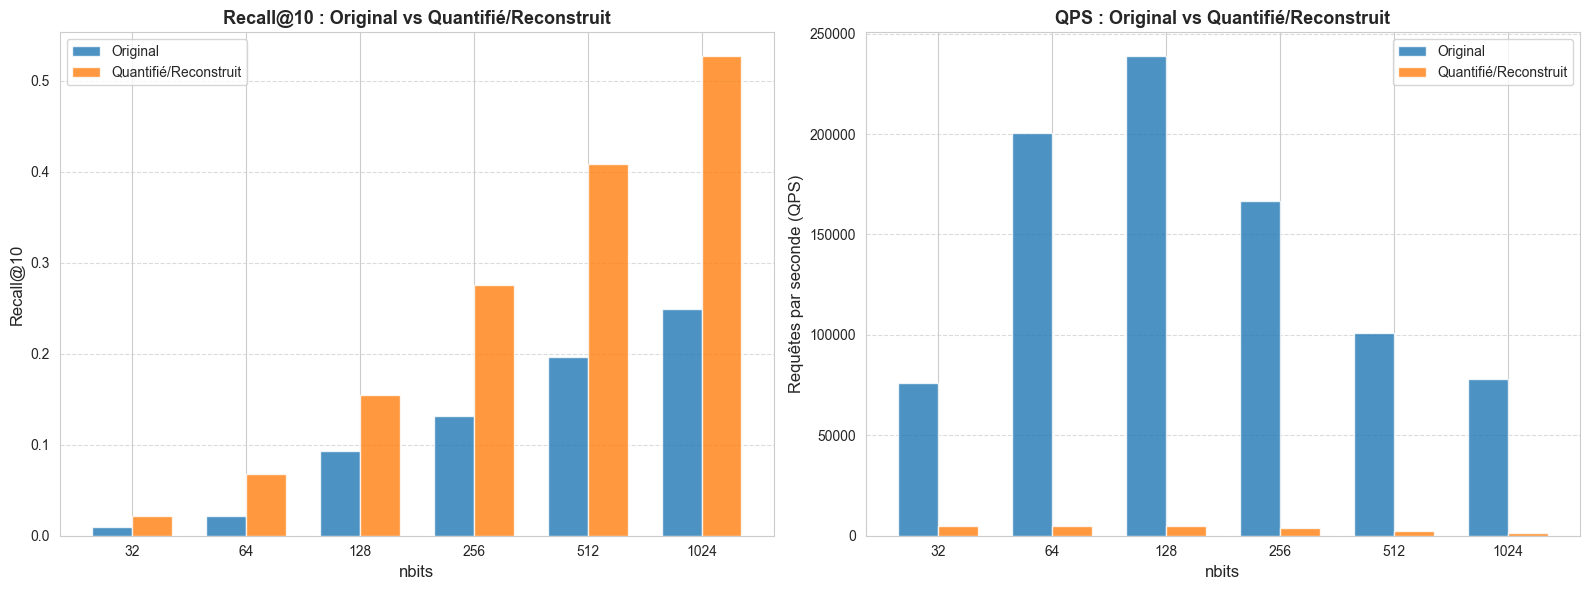

✓ Graphique sauvegardé dans ./results/lsh_comparison_original_vs_reconstructed.png


In [14]:
# ============================================
# COMPARAISON : ORIGINAL vs QUANTIFIÉ/RECONSTRUIT
# ============================================

# Ajout QPS au DataFrame original si absent
df_original = df_results.copy()
if 'QPS' not in df_original.columns:
    df_original['QPS'] = 1000 / df_original['Latency (ms)']

# Tableau comparatif
df_comparison = pd.DataFrame({
    'nbits': df_original['nbits'],
    'Recall@10 (original)': df_original['Recall@10'].values,
    'Recall@10 (quantifié/reconstruit)': df_reconstructed['Recall@10'].values,
    'Delta Recall': df_reconstructed['Recall@10'].values - df_original['Recall@10'].values,
    'QPS (original)': df_original['QPS'].values,
    'QPS (quantifié/reconstruit)': df_reconstructed['QPS'].values,
})

print("=" * 70)
print("COMPARAISON ORIGINAL vs QUANTIFIÉ/RECONSTRUIT")
print("=" * 70)
display(df_comparison.style.format({
    'Recall@10 (original)': '{:.4f}',
    'Recall@10 (quantifié/reconstruit)': '{:.4f}',
    'Delta Recall': '{:+.4f}',
    'QPS (original)': '{:.1f}',
    'QPS (quantifié/reconstruit)': '{:.1f}',
}))

# Export CSV comparaison
df_comparison.to_csv(f"{RESULTS_PATH}lsh_comparison_original_vs_reconstructed.csv", index=False)
print(f"\n✓ Comparaison exportée dans {RESULTS_PATH}lsh_comparison_original_vs_reconstructed.csv")

# --- Graphiques côte à côte ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

x = np.arange(len(nbits_list))
width = 0.35

# Recall@10
ax1 = axes[0]
ax1.bar(x - width/2, df_original['Recall@10'], width, label='Original', color='#1f77b4', alpha=0.8)
ax1.bar(x + width/2, df_reconstructed['Recall@10'], width, label='Quantifié/Reconstruit', color='#ff7f0e', alpha=0.8)
ax1.set_title('Recall@10 : Original vs Quantifié/Reconstruit', fontsize=13, fontweight='bold')
ax1.set_xlabel('nbits', fontsize=12)
ax1.set_ylabel('Recall@10', fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels([str(n) for n in nbits_list])
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# QPS
ax2 = axes[1]
ax2.bar(x - width/2, df_original['QPS'], width, label='Original', color='#1f77b4', alpha=0.8)
ax2.bar(x + width/2, df_reconstructed['QPS'], width, label='Quantifié/Reconstruit', color='#ff7f0e', alpha=0.8)
ax2.set_title('QPS : Original vs Quantifié/Reconstruit', fontsize=13, fontweight='bold')
ax2.set_xlabel('nbits', fontsize=12)
ax2.set_ylabel('Requêtes par seconde (QPS)', fontsize=12)
ax2.set_xticks(x)
ax2.set_xticklabels([str(n) for n in nbits_list])
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig(f"{RESULTS_PATH}lsh_comparison_original_vs_reconstructed.png", dpi=300)
plt.show()
print(f"✓ Graphique sauvegardé dans {RESULTS_PATH}lsh_comparison_original_vs_reconstructed.png")